In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../../datasets/Salary_Data.csv')
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


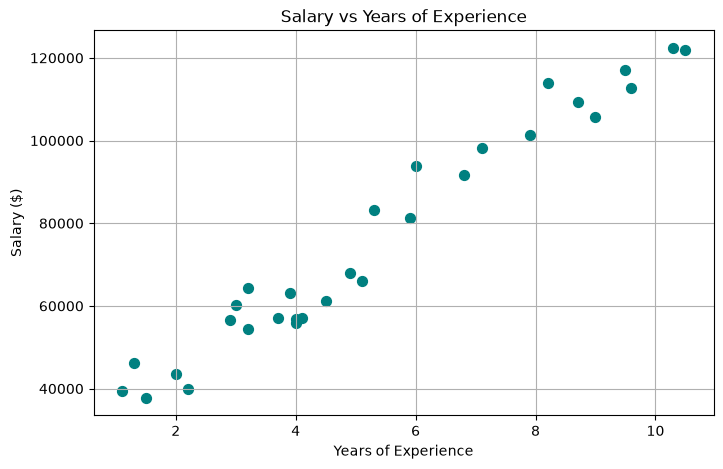

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='teal', s=50)
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.grid(True)
plt.show()

In [4]:
X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [5]:
b_0 = model.intercept_
b_1 = model.coef_[0]

print(f'Intercept (b_0): {b_0:.2f}')
print(f'Slope (b_1): {b_1:.2f}')
print(f'Regression Equation: h(x) = {b_0:.2f} + {b_1:.2f} * x')

Intercept (b_0): 25321.58
Slope (b_1): 9423.82
Regression Equation: h(x) = 25321.58 + 9423.82 * x


In [6]:
new_candidates = pd.DataFrame({'YearsExperience': [1.5, 3.5, 6.0, 9.0, 12.0]})
predicted_salaries = model.predict(new_candidates)

for exp, sal in zip(new_candidates['YearsExperience'], predicted_salaries):
    print(f'Experience: {exp} years -> Predicted Starting Salary: ')

Experience: 1.5 years -> Predicted Starting Salary: 
Experience: 3.5 years -> Predicted Starting Salary: 
Experience: 6.0 years -> Predicted Starting Salary: 
Experience: 9.0 years -> Predicted Starting Salary: 
Experience: 12.0 years -> Predicted Starting Salary: 


In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.4f}')

MAE: 6286.45
MSE: 49830096.86
RMSE: 7059.04
R2 Score: 0.9024


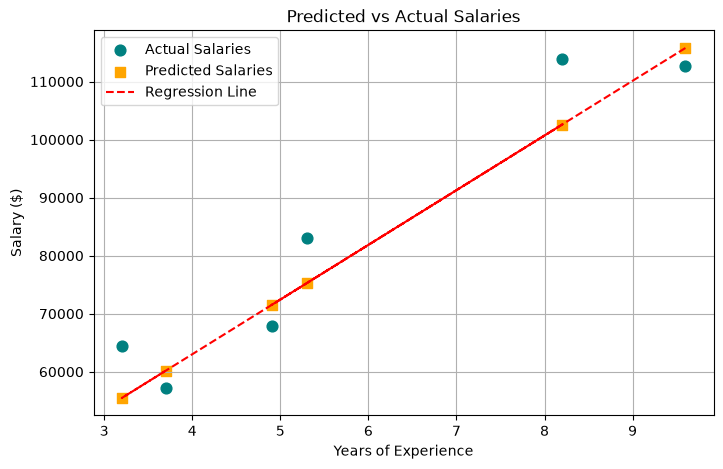

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='teal', label='Actual Salaries', s=60)
plt.scatter(X_test, y_pred, color='orange', marker='s', label='Predicted Salaries', s=60)
plt.plot(X_test, y_pred, color='red', linestyle='--', label='Regression Line')
plt.title('Predicted vs Actual Salaries')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend()
plt.grid(True)
plt.show()